In [27]:
# Общие библиотеки
import os
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import dask.dataframe as dd
import dask_ml
from dask_ml.model_selection import train_test_split
from dask_ml.linear_model import LogisticRegression
import dask.array as da

# Scikit-learn для задач машинного обучения
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# XGBoost для продвинутого градиентного бустинга
import xgboost as xgb

# Конвейеры (pipelines) и трансформеры Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Метрики оценки
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [28]:
# зафиксируем условия работы генератора случайных чисел для воспроизводимости процессов
seed = 1234
np.random.seed(seed)

In [29]:
import kagglehub

# Скачаем самую свежую версию данных
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
new_file = os.path.join(path, os.listdir(path)[0])

In [30]:
data_path = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data', 'credit-card-fraud')
if not os.path.exists(data_path):
    os.makedirs(data_path)

In [31]:
# перенесём файл в локальное рабочее пространство
shutil.copy(new_file, data_path)
train_path = os.path.join(data_path, os.listdir(data_path)[0])

In [32]:
df = pd.read_csv(train_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
#попытка использовать dask не показала улучшения, даже напротив, всё стало считаться сильно медленее..
# вернулся на классику пока


# df = dd.read_csv(train_path, assume_missing=True)
# df.tail()

Проверим распределение данных

In [34]:
print(df['Class'].value_counts())
print(round(df['Class'].value_counts()[1]*100/df['Class'].value_counts()[0],4), "%")

Class
0    284315
1       492
Name: count, dtype: int64
0.173 %


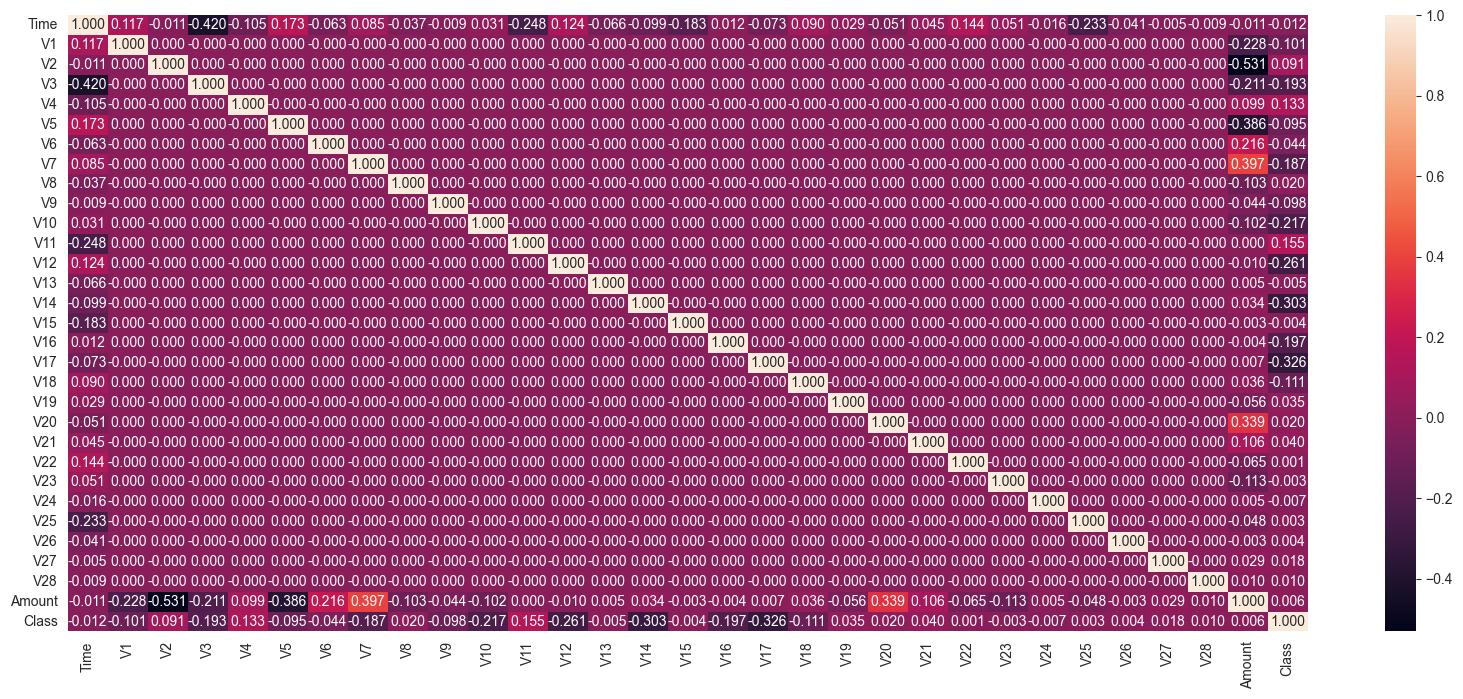

In [35]:
columns = df.select_dtypes(include = ['int', 'float'])
plt.figure(figsize = (20,8))
sns.heatmap(columns.corr(), annot=True, fmt='.3f')
plt.show()

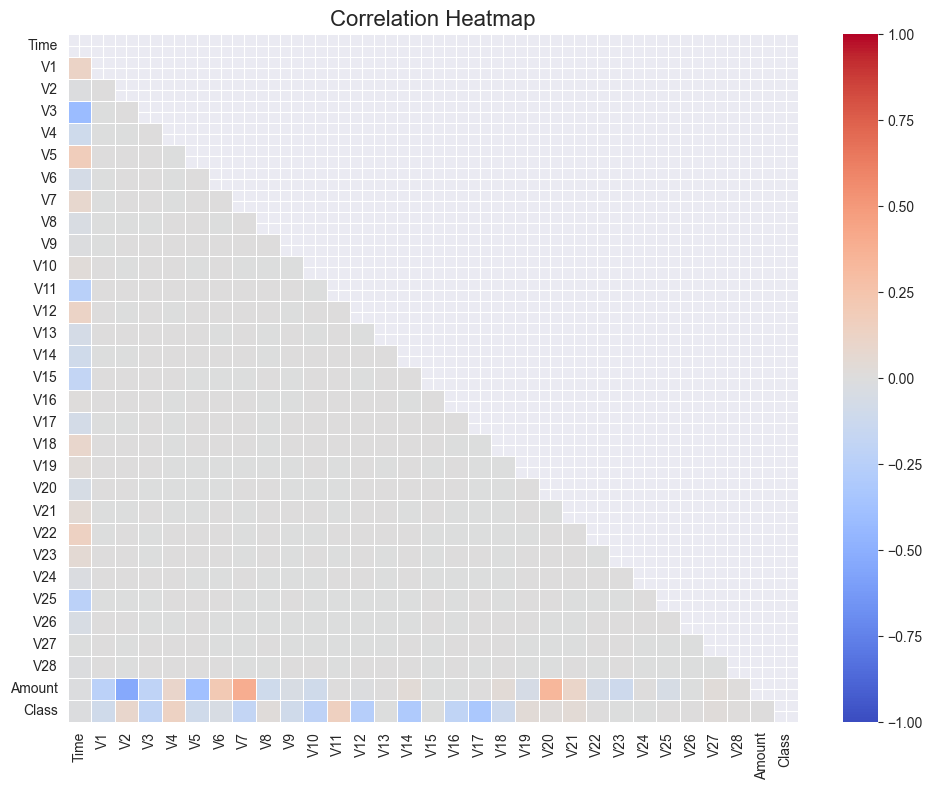


Top 10 Features Correlated with Class:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


In [36]:
# Корреляционная матрица признаков
plt.figure(figsize=(10, 8))
correlation = df.corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=False, cmap='coolwarm', mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Топ 10 признаков, коррелирующих с классом
class_corr = correlation['Class'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Class:")
print(class_corr[1:11])  # Exclude Class itself

In [37]:
# Признаки (X) - это все столбцы, кроме "Class"
X = df.drop('Class', axis=1)

# Цель (y) — столбец «Класс»
y = df['Class']

print(f"Форма признаков Х: {X.shape}")
print(f"Форма целевой переменной У: {y.shape}")
print("\nПервые 5 строк X:")
print(X.head())
print("\nПервые 5 значений y:")
print(y.head())

Форма признаков Х: (284807, 30)
Форма целевой переменной У: (284807,)

Первые 5 строк X:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  .

In [38]:
X['Amount'].head

<bound method NDFrame.head of 0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64>

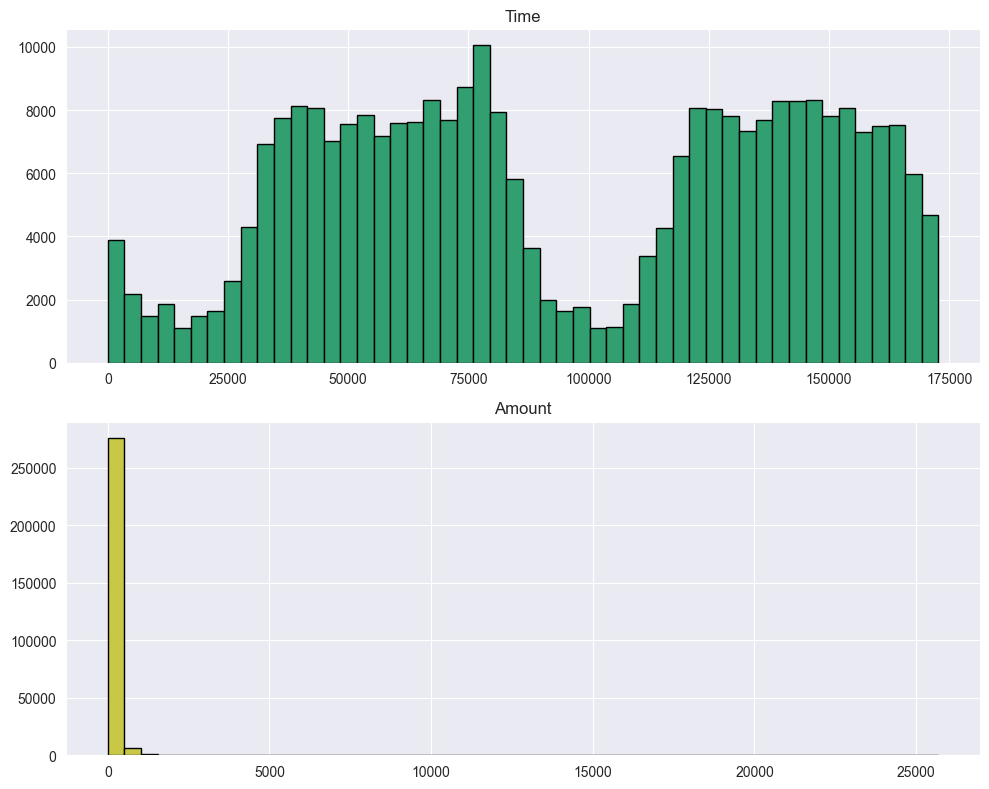

In [39]:
time_amount_cl = ['Time', 'Amount']
time_amount = df[time_amount_cl]

plt.figure(figsize=(10, 8))

np.random.seed(seed)
for idx, numeric in enumerate(time_amount_cl) :
    col = (np.random.random(), np.random.random(), np.random.random())

    plt.subplot(2, 1, idx+1)
    plt.hist(time_amount[numeric], bins=50, color=col, edgecolor='black')
    plt.title(numeric)
    plt.tight_layout()

plt.tight_layout()
plt.show()

In [40]:
# Посмотрим все распределения
Vs_columns = ['V1',  'V2',  'V3',  'V4',  'V5',  'V6',  'V7',  'V8',  'V9',  'V10',
              'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
              'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Vs_data = df[Vs_columns]

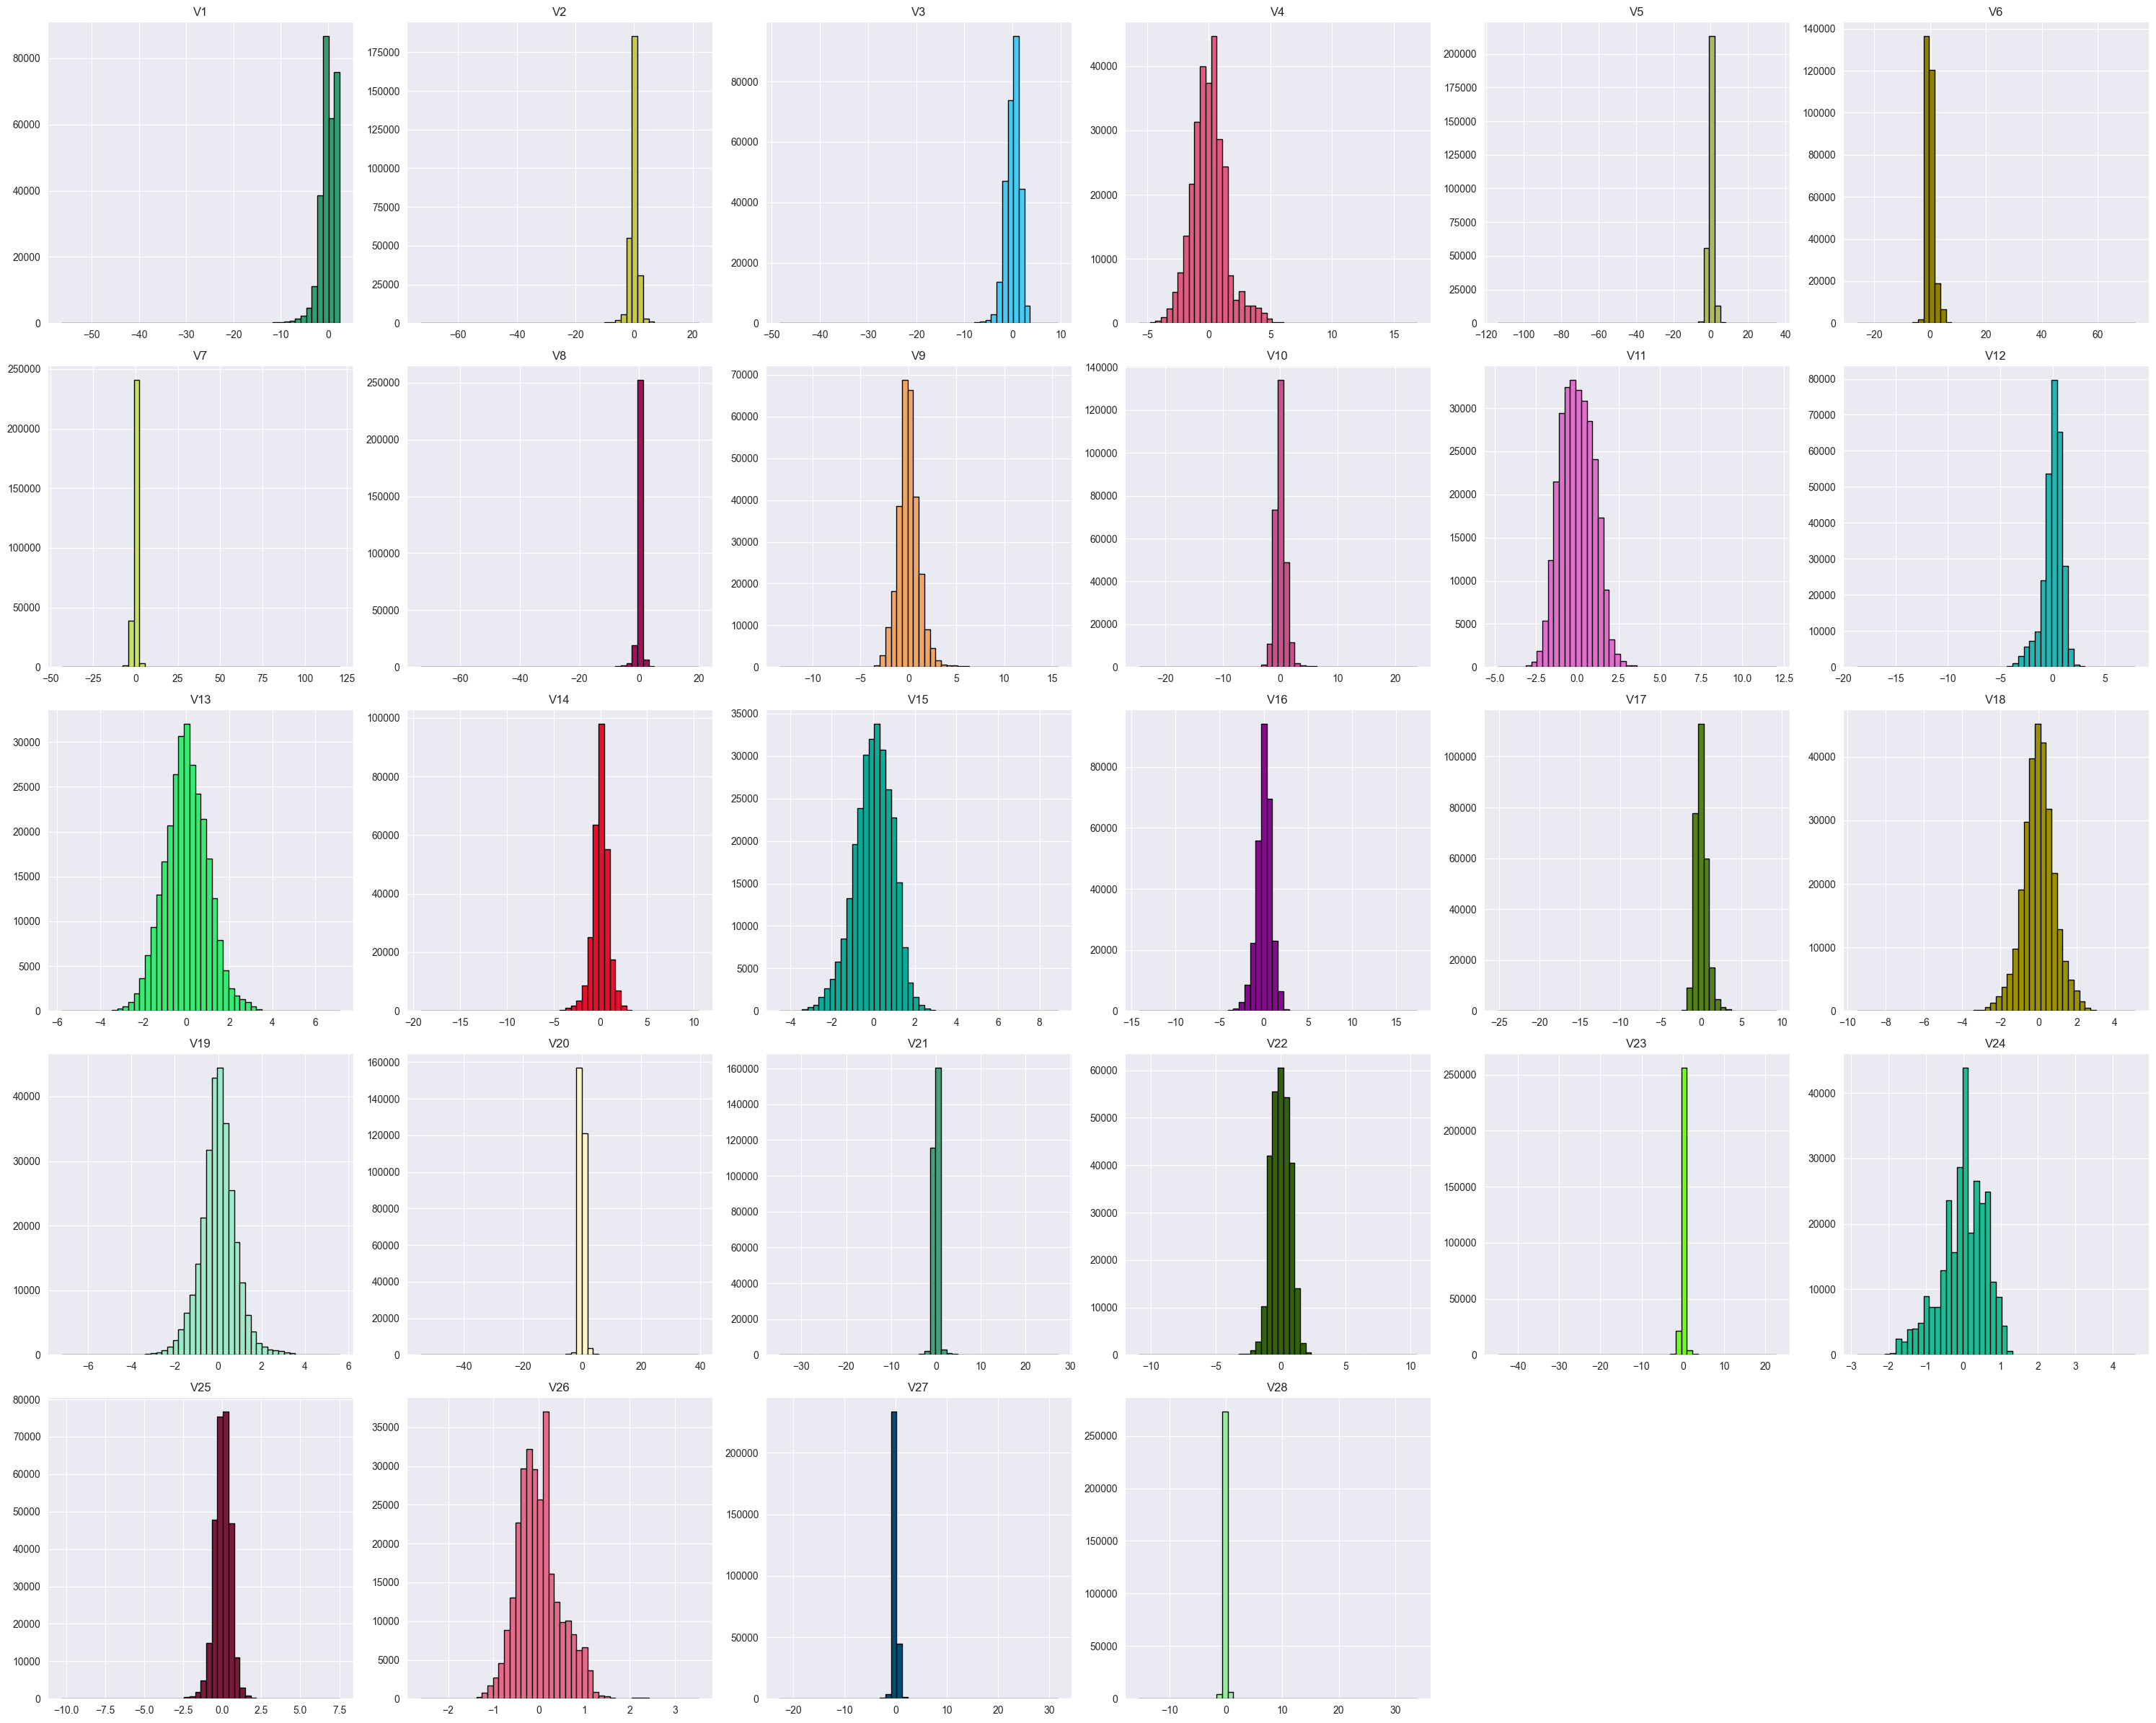

In [41]:
plt.figure(figsize=(30, 24))

np.random.seed(seed)
for idx, numeric in enumerate(Vs_columns) :
    col = (np.random.random(), np.random.random(), np.random.random())

    plt.subplot(5, 6, idx+1)
    plt.hist(Vs_data[numeric], bins=50, color=col, edgecolor='black')
    plt.title(numeric)
    plt.tight_layout()

plt.tight_layout()
plt.show()

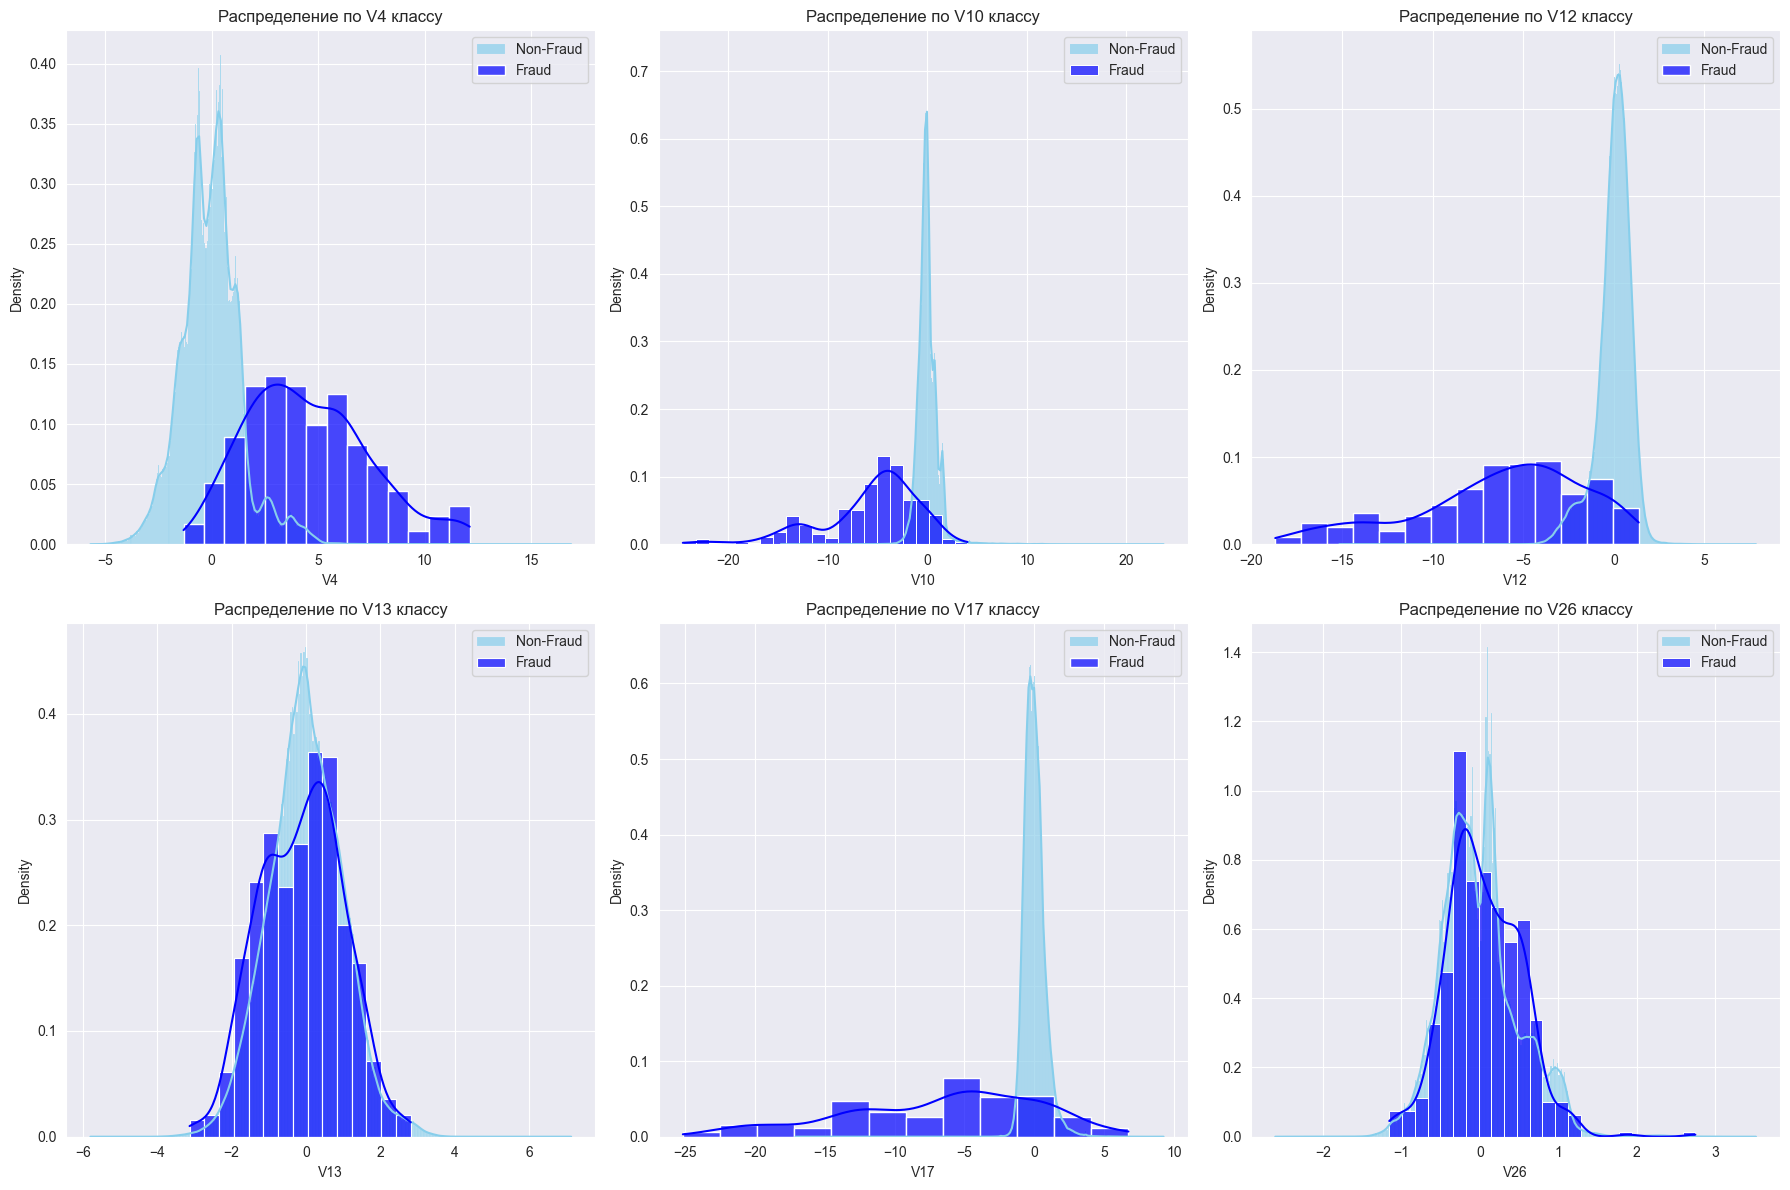

In [42]:
# подмножество V-признаков, которые часто являются высокодискриминационными с точки зрения мошенничества
v_fts_to_plot = ['V4', 'V10', 'V12', 'V13', 'V17', 'V26']

plt.figure(figsize=(18, 12))
for i, ft in enumerate(v_fts_to_plot):
    plt.subplot(2, 3, i + 1) # Расположим графики в виде сетки 2x3
    sns.histplot(df[df['Class'] == 0][ft], kde=True, color='skyblue', label='Non-Fraud', stat='density', alpha=0.7)
    sns.histplot(df[df['Class'] == 1][ft], kde=True, color='blue', label='Fraud', stat='density', alpha=0.7)
    plt.title(f'Распределение по {ft} классу')
    plt.xlabel(ft)
    plt.ylabel('Density')
    plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Определим числовые признаки, требующие масштабирования
# "Время" и "Количество" - это необработанные числовые признаки, которые нуждаются в стандартизации.

num_ft_to_scale = ['Time', 'Amount']

# Функции "V" (V1-V28) уже преобразованы в PCA и эффективно масштабируются.
# Мы пропустим их без дальнейших преобразований.

no_scale_ft = [col for col in X.columns if col.startswith('V')]

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), num_ft_to_scale)
    ],
    remainder='passthrough'
)

In [45]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# n_splits=5: Мы будем использовать 5 циклов для перекрестной проверки.
# shuffle=True: Перетасовывает данные перед разделением, что важно для случайности.
# random_state=42: фиксируем генератор случайных чисел для воспроизводимости результатов.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# test_size=0.2: 20% данных будет использовано для тестирования, 80% — для обучения.
# random_state=42: фиксируем генератор случайных чисел для воспроизводимости результатов.
# stratify=y: Это гарантирует, что доля мошеннических (класс 1) и немошеннических транзакций (класс 0) одинакова как в обучающем, так и в тестовом наборах, как и в исходном наборе данных.

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

# Проверка распределения классов в разбиениях
print("\nРаспределение классов в учебном наборе:")
print(y_train.value_counts(normalize=True))
print("Распределение классов в тестовом наборе:")
print(y_test.value_counts(normalize=True))

# подтвердить, что количество случаев мошенничества постоянно
print(f"\nМошеннические случаи в учебном наборе: {y_train.sum()}")
print(f"Мошеннические случаи в тестовом наборе: {y_test.sum()}")


X_train: (227845, 30)
y_train: (227845,)
X_test: (56962, 30)
y_test: (56962,)

Распределение классов в учебном наборе:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Распределение классов в тестовом наборе:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

Мошеннические случаи в учебном наборе: 394
Мошеннические случаи в тестовом наборе: 98


In [46]:
# --- Определяем модель ---
models = {
    'Logistic_Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Decision_Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random_Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(random_state=42,  eval_metric='logloss',scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))
    # cale_pos_weight — это способ XGBoost справиться с дисбалансом, похожий на class_weight
}

# --- Определение сеток гиперпараметров для GridSearchCV ---
# Эти сетки определяют диапазоны гиперпараметров для поиска наилучшей конфигурации модели.

param_grids = {
    'Logistic_Regression': {
        'classificator__C': [0.01, 0.1, 1, 10] # Обратная сила регуляризации; меньший C означает более сильную регуляризацию
    },
    'Decision_Tree': {
        'classificator__max_depth': [3, 5, 7, None], # Максимальная глубина залегания дерева; Нет значит неограниченно
        'classificator__min_samples_leaf': [1, 5, 10] # Минимальное количество образцов, необходимое для нахождения в листовом узле
    },
    'Random_Forest': {
        'classificator__n_estimators': [100, 200], # Количество деревьев в лесу
        'classificator__max_depth': [5, 10], # Максимальная глубина дерева
        'classificator__min_samples_leaf': [5, 10] # Минимальное количество образцов на лист для каждого дерева
    },
    'XGBoost': {
        'classificator__n_estimators': [100, 200], # Количество итераций бустинга (деревьев)
        'classificator__max_depth': [3, 5], # Максимальная глубина дерева
        'classificator__learning_rate': [0.01, 0.1] # Уменьшение размера шага (shrinkage) для предотвращения переобучения
    }
}

results = {} # Словарь для хранения метрик производительности для сравнения между моделями


===== Настройка и обучение: Logistic_Regression =====
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры для Logistic_Regression: {'classificator__C': 0.01}

Эффективность для Logistic_Regression на Тестовом наборе:
  Правильность (вводит в заблуждение из-за дисбаланса): 0.9758
  Точность (класс мошенничества): 0.0616
  Полнота (класс мошенничества): 0.9184
  F1 (класс мошенничества): 0.1155
  ROC AUC показатель: 0.9725
  Матрица ошибок:


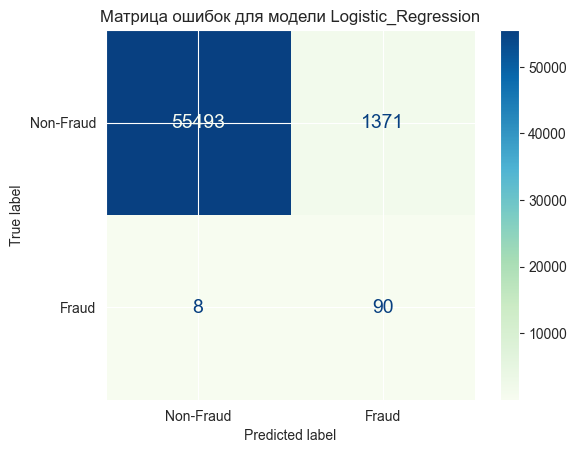


--- Коэффициенты для модели Logistic_Regression (Logistic_Regression) ---
               Feature  Coefficient
5        remainder__V4     0.921443
1   num_scaler__Amount     0.825811
23      remainder__V22     0.602663
29      remainder__V28     0.445728
6        remainder__V5     0.405913
2        remainder__V1     0.402664
12      remainder__V11     0.317884
22      remainder__V21     0.186667
3        remainder__V2     0.063334
20      remainder__V19     0.038436

Признаки с наиболее негативными коэффициентами:
             Feature  Coefficient
27    remainder__V26    -0.337347
0   num_scaler__Time    -0.365706
14    remainder__V13    -0.410455
9      remainder__V8    -0.471115
21    remainder__V20    -0.559016
18    remainder__V17    -0.605658
17    remainder__V16    -0.760113
13    remainder__V12    -0.767678
11    remainder__V10    -0.894750
15    remainder__V14    -1.132370

===== Настройка и обучение: Decision_Tree =====
Fitting 5 folds for each of 12 candidates, totalling 60 f

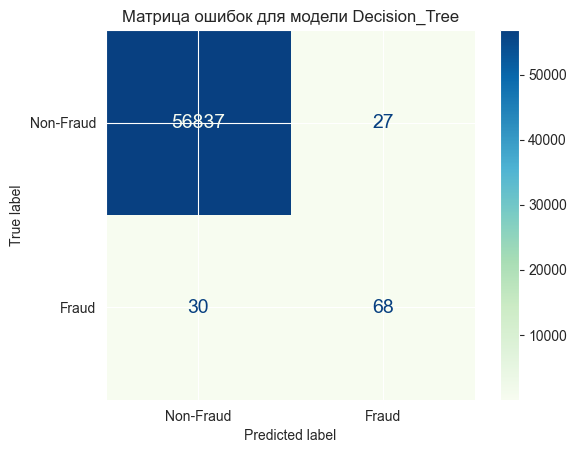


--- Важность признаков для модели Decision_Tree ---
           Feature  important
15  remainder__V14   0.732875
5    remainder__V4   0.067405
13  remainder__V12   0.025502
14  remainder__V13   0.021932
9    remainder__V8   0.016462
19  remainder__V18   0.015162
21  remainder__V20   0.014462
16  remainder__V15   0.012230
11  remainder__V10   0.011879
8    remainder__V7   0.010971


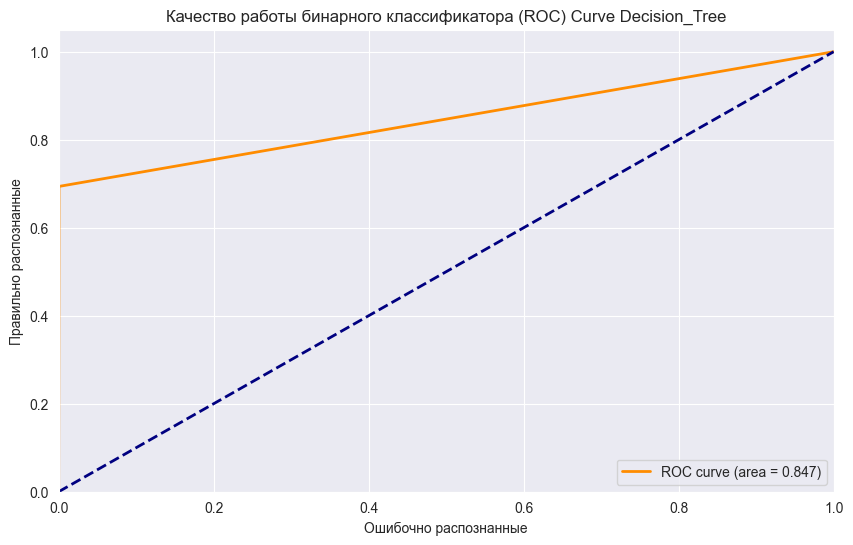

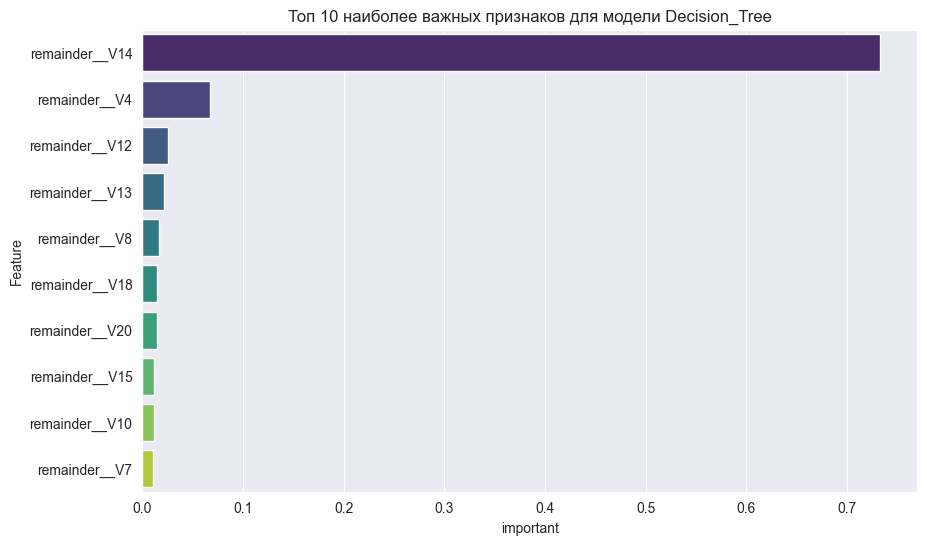


===== Настройка и обучение: Random_Forest =====
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры для Random_Forest: {'classificator__max_depth': 10, 'classificator__min_samples_leaf': 5, 'classificator__n_estimators': 100}

Эффективность для Random_Forest на Тестовом наборе:
  Правильность (вводит в заблуждение из-за дисбаланса): 0.9993
  Точность (класс мошенничества): 0.7593
  Полнота (класс мошенничества): 0.8367
  F1 (класс мошенничества): 0.7961
  ROC AUC показатель: 0.9746
  Матрица ошибок:


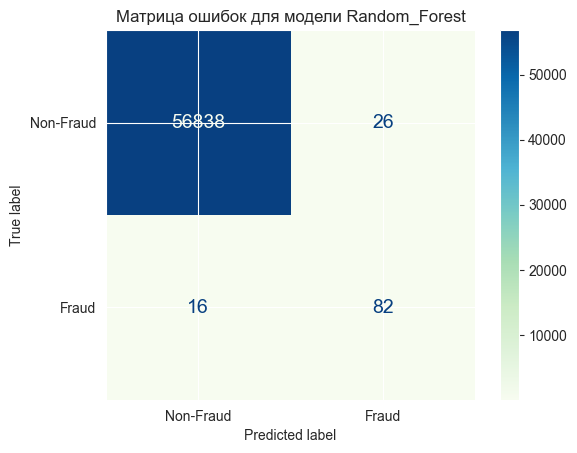


--- Важность признаков для модели Random_Forest ---
           Feature  important
15  remainder__V14   0.226665
13  remainder__V12   0.138189
5    remainder__V4   0.112119
11  remainder__V10   0.080153
12  remainder__V11   0.075918
18  remainder__V17   0.063503
4    remainder__V3   0.048615
8    remainder__V7   0.034995
3    remainder__V2   0.024029
17  remainder__V16   0.020179


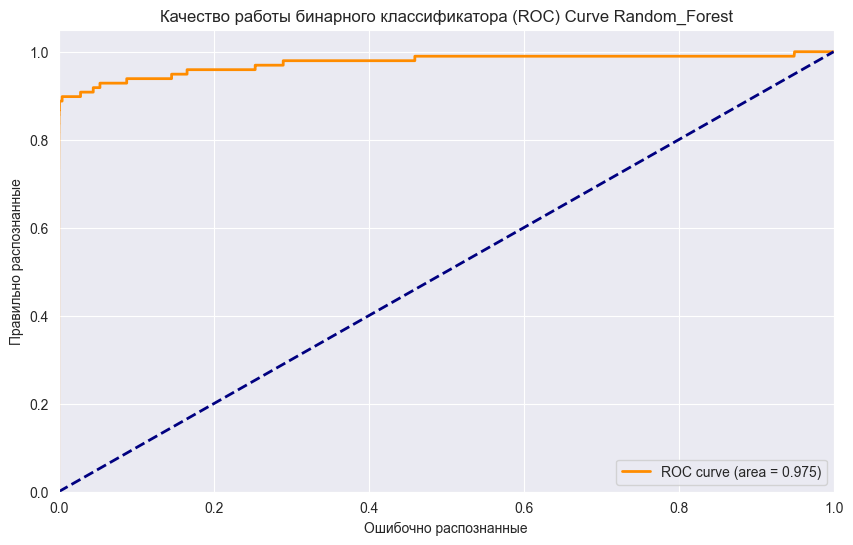

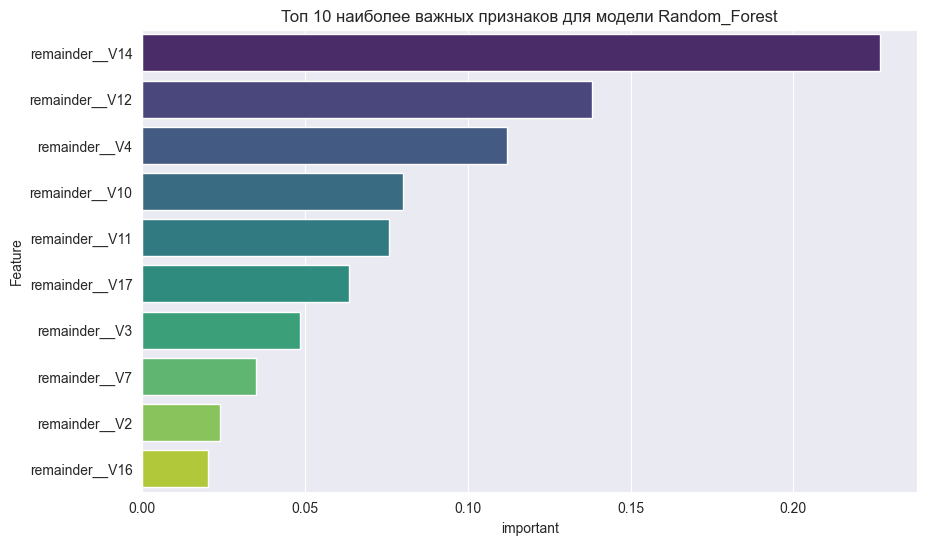


===== Настройка и обучение: XGBoost =====
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры для XGBoost: {'classificator__learning_rate': 0.1, 'classificator__max_depth': 5, 'classificator__n_estimators': 200}

Эффективность для XGBoost на Тестовом наборе:
  Правильность (вводит в заблуждение из-за дисбаланса): 0.9994
  Точность (класс мошенничества): 0.8367
  Полнота (класс мошенничества): 0.8367
  F1 (класс мошенничества): 0.8367
  ROC AUC показатель: 0.9778
  Матрица ошибок:


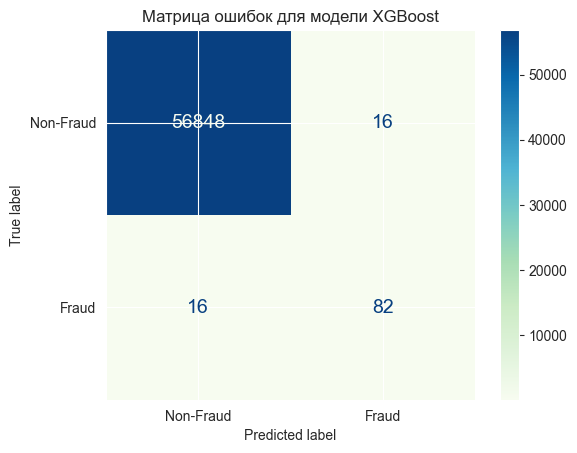


--- Важность признаков для модели XGBoost ---
               Feature  important
15      remainder__V14   0.514525
5        remainder__V4   0.067818
13      remainder__V12   0.042477
9        remainder__V8   0.028996
1   num_scaler__Amount   0.021902
8        remainder__V7   0.020270
21      remainder__V20   0.019243
11      remainder__V10   0.019143
14      remainder__V13   0.018105
29      remainder__V28   0.017853


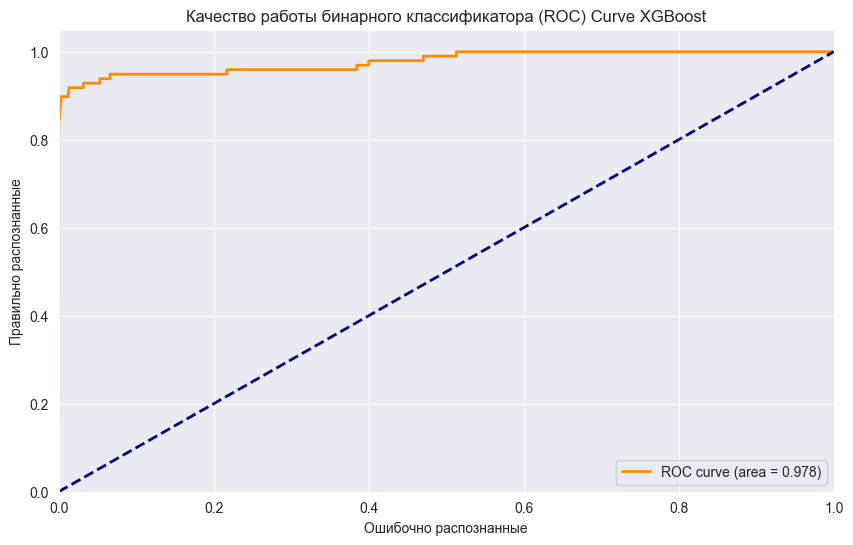

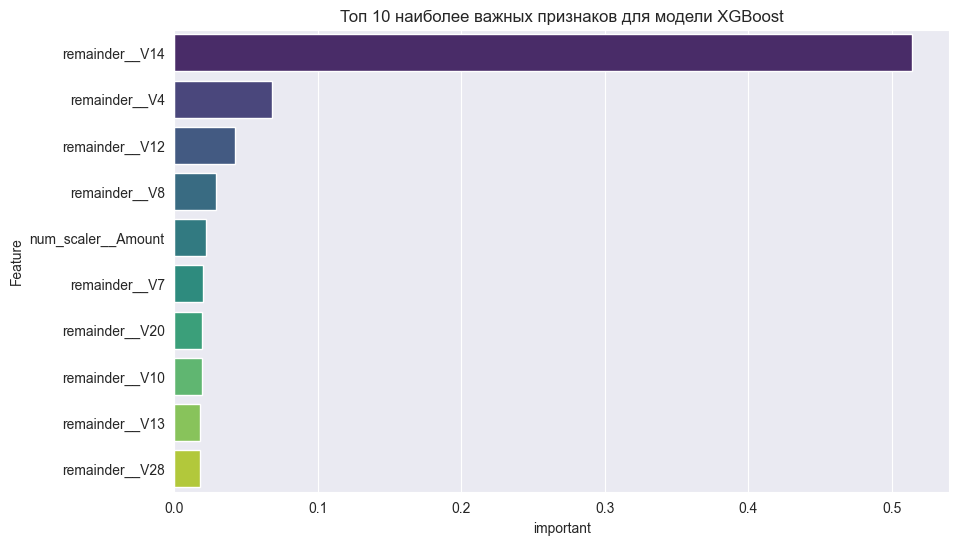

In [142]:
for model_name, model in models.items():
    print(f"\n===== Настройка и обучение: {model_name} =====")

    # Создадим полный конвейер: предварительная обработка -> классификатор
    # Это обеспечивает последовательное масштабирование в каждой итерации GridSearchCV.

    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classificator', model)])

    # Выполним GridSearchCV для настройки гиперпараметров.
    # estimator: Конвейер для настройки.
    # param_grid: Конкретная сетка гиперпараметров для текущей модели.
    # cv=skf: Используем StratifiedKFold для перекрестной проверки, чтобы поддерживать баланс классов в каждой сворачивании.
    # scoring="f1": Оптимизируем GridSearchCV на основе F1-оценки класса меньшинства, который подходит для дисбаланса.
    # n_jobs=-1: Используем все доступные ядра процессора для более быстрых вычислений.
    # verbose=1: Печать сообщений о прогрессе.
    grid_srchcv = GridSearchCV(full_pipeline, param_grids[model_name], cv=skf, scoring='f1', n_jobs=-1, verbose=1)
    grid_srchcv.fit(X_train, y_train) # Подгонка GridSearchCV по обучающим данным

    # Сохраним лучшую модель и ее параметры
    bestModel = grid_srchcv.best_estimator_
    results[model_name] = {'Лучшая модель': bestModel, 'Лучшие параметры': grid_srchcv.best_params_}

    print(f"Лучшие параметры для {model_name}: {grid_srchcv.best_params_}")

    # --- Оценим лучшую модель на тестовом наборе ---
    # Рассчитаем прогнозы на тестовом наборе
    y_pred = bestModel.predict(X_test)
    # Получим оценку вероятности для положительного класса (мошенничество) для расчета ROC AUC
    y_proba = bestModel.predict_proba(X_test)[:, 1]

    # Рассчитаем и сохраним метрики эффективности
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    conf_matrix = confusion_matrix(y_test, y_pred)

    results[model_name].update({
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': conf_matrix
    })

    print(f"\nЭффективность для {model_name} на Тестовом наборе:")
    print(f"  Правильность (вводит в заблуждение из-за дисбаланса): {accuracy:.4f}")
    print(f"  Точность (класс мошенничества): {precision:.4f}")
    print(f"  Полнота (класс мошенничества): {recall:.4f}")
    print(f"  F1 (класс мошенничества): {f1:.4f}")
    print(f"  ROC AUC показатель: {roc_auc:.4f}")
    print("  Матрица ошибок:")
    
    # Визуализация матрицы несоответствий
    cmd_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Non-Fraud', 'Fraud'])
    cmd_display.plot(cmap='GnBu', values_format='d') # 'd' for integer format
    ax = cmd_display.ax_
    # Увеличиваем размер шрифта цифр в ячейках матрицы
    for text in ax.texts:
        text.set_fontsize(14)   # выберите желаемый размер
    plt.title(f'Матрица ошибок для модели {model_name}')
    plt.show()

    if hasattr(bestModel.named_steps['classificator'], 'feature_importances_'):
        print(f"\n--- Важность признаков для модели {model_name} ---")
        feature_importants = bestModel.named_steps['classificator'].feature_importances_

        featureNames = bestModel.named_steps['preprocessor'].get_feature_names_out()

        # Создадим DataFrame для лучшей визуализации и сортировки
        important_df = pd.DataFrame({
            'Feature': featureNames,
            'important': feature_importants
        }).sort_values(by='important', ascending=False)

        print(important_df.head(10)) # Отобразим 10 наиболее важных признаков

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(10, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Ошибочно распознанные')
        plt.ylabel('Правильно распознанные')
        plt.title(f'Качество работы бинарного классификатора (ROC) Curve {model_name}')   
        plt.legend(loc="lower right")
        plt.show()
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='important', y='Feature', data=important_df.head(10), hue='Feature', palette='viridis', legend=False)
        plt.title(f'Топ 10 наиболее важных признаков для модели {model_name}')
        plt.show()

    # Извлечём коэффициенты для линейных моделей (например, логистическая регрессия)
    elif hasattr(bestModel.named_steps['classificator'], 'coef_'):
        print(f"\n--- Коэффициенты для модели {model_name} (Logistic_Regression) ---")
        coefficients = bestModel.named_steps['classificator'].coef_[0] # Для бинарной классификации, coef_ - 2d
        featureNames = bestModel.named_steps['preprocessor'].get_feature_names_out()

        coef_df = pd.DataFrame({
            'Feature': featureNames,
            'Coefficient': coefficients
        }).sort_values(by='Coefficient', ascending=False)
        print(coef_df.head(10)) # Отобразим признаки с самыми большими положительными коэффициентами
        print("\nПризнаки с наиболее негативными коэффициентами:")
        print(coef_df.tail(10)) # Отобразим признаки с самыми большими отрицательными коэффициентами

In [130]:
# Заведём датафрейм, чтобы суммировать результаты для исполнительного резюме
summary_data = []
for model_name, metrics in results.items():
    # Убедимся, что метрики доступны перед попыткой получить доступ к ним
    if 'accuracy' in metrics:
        summary_data.append({
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision (Fraud)': metrics['precision'],
            'Recall (Fraud)': metrics['recall'],
            'F1-Score (Fraud)': metrics['f1_score'],
            'ROC AUC': metrics['roc_auc']
        })

        performance_summary_df = pd.DataFrame(summary_data).set_index('Model')
        print(performance_summary_df.round(4))
        
        # Определим лучшую модель на основе F1-показателя (поскольку она уравновешивает точность и отзыв)
        best_f1_model_name = performance_summary_df['F1-Score (Fraud)'].idxmax()
        print(f"\nЛучшая модель на F1-Score: **{best_f1_model_name}**")


                     Accuracy  Precision (Fraud)  Recall (Fraud)  \
Model                                                              
Logistic_Regression    0.9758             0.0616          0.9184   

                     F1-Score (Fraud)  ROC AUC  
Model                                           
Logistic_Regression            0.1155   0.9725  

Лучшая модель на F1-Score: **Logistic_Regression**
                     Accuracy  Precision (Fraud)  Recall (Fraud)  \
Model                                                              
Logistic_Regression    0.9758             0.0616          0.9184   
Decision_Tree          0.9990             0.7158          0.6939   

                     F1-Score (Fraud)  ROC AUC  
Model                                           
Logistic_Regression            0.1155   0.9725  
Decision_Tree                  0.7047   0.8467  

Лучшая модель на F1-Score: **Decision_Tree**
                     Accuracy  Precision (Fraud)  Recall (Fraud)  \
Model        